# Improved RNN Model for IMDB Sentiment Analysis

This notebook implements an improved RNN model using:
- Bidirectional LSTM architecture
- Dropout layers for regularization
- Learning rate scheduling
- Pre-trained GloVe embeddings
- Better text preprocessing

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import re
import os
import requests
import zipfile
import io

In [2]:
# Parameters
max_features = 10000  # Vocabulary size
max_len = 500  # Maximum sequence length
embedding_dim = 100  # Dimension of GloVe embeddings
batch_size = 32  # Smaller batch size for better generalization
epochs = 15  # More epochs with early stopping

## Load and Preprocess the IMDB Dataset

In [3]:
# Load the IMDB dataset
print("Loading IMDB dataset...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences to ensure uniform input size
X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

# Get word index for later use
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Loading IMDB dataset...
Training data shape: (25000, 500)
Testing data shape: (25000, 500)


## Download and Load GloVe Embeddings

In [4]:
# Function to download GloVe embeddings if not already downloaded
def download_glove_embeddings():
    glove_dir = 'glove'
    if not os.path.exists(glove_dir):
        os.makedirs(glove_dir)
    
    glove_path = os.path.join(glove_dir, 'glove.6B.100d.txt')
    if not os.path.exists(glove_path):
        print("Downloading GloVe embeddings...")
        url = "https://nlp.stanford.edu/data/glove.6B.zip"
        r = requests.get(url)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(glove_dir)
        print("Download complete!")
    else:
        print("GloVe embeddings already downloaded.")
    
    return glove_path

In [5]:
# Load GloVe embeddings
def load_glove_embeddings(glove_path):
    print("Loading GloVe embeddings...")
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    
    print(f"Found {len(embeddings_index)} word vectors.")
    
    # Create embedding matrix
    embedding_matrix = np.zeros((max_features, embedding_dim))
    for word, i in word_index.items():
        if i < max_features:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
    
    return embedding_matrix

In [6]:
# Try to download and load GloVe embeddings
try:
    glove_path = download_glove_embeddings()
    embedding_matrix = load_glove_embeddings(glove_path)
    use_glove = True
except Exception as e:
    print(f"Error loading GloVe embeddings: {e}")
    print("Continuing without pre-trained embeddings.")
    use_glove = False

GloVe embeddings already downloaded.
Loading GloVe embeddings...
Found 400000 word vectors.


## Build the Improved Model

In [7]:
# Build an improved model with LSTM, Bidirectional, and Dropout
print("Building model...")
model = Sequential()

# Add embedding layer (with or without pre-trained embeddings)
if use_glove:
    model.add(Embedding(max_features, embedding_dim, 
                       weights=[embedding_matrix],
                       input_length=max_len,
                       trainable=False))  # Freeze the embeddings initially
else:
    model.add(Embedding(max_features, embedding_dim, input_length=max_len))

# Add Bidirectional LSTM layers with dropout
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model with a lower learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Display model summary
model.summary()

Building model...

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 500, 100)          1000000   
                                                                 
 bidirectional (Bidirection  (None, 500, 128)          84480     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 500, 128)          0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1

## Train the Model with Callbacks

In [8]:
# Set up callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001
)

In [9]:
# Train the model
print("Training model...")
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr]
)

Training model...
Epoch 1/15


625/625 [==============================] - 366s 577ms/step - loss: 0.6857 - accuracy: 0.5486 - val_loss: 0.6433 - val_accuracy: 0.6364 - lr: 0.0010
Epoch 2/15
625/625 [==============================] - 311s 498ms/step - loss: 0.6288 - accuracy: 0.6449 - val_loss: 0.5851 - val_accuracy: 0.6824 - lr: 0.0010
Epoch 3/15
625/625 [==============================] - 335s 536ms/step - loss: 0.5649 - accuracy: 0.7061 - val_loss: 0.5438 - val_accuracy: 0.7156 - lr: 0.0010
Epoch 4/15
625/625 [==============================] - 336s 537ms/step - loss: 0.5119 - accuracy: 0.7436 - val_loss: 0.5266 - val_accuracy: 0.7322 - lr: 0.0010
Epoch 5/15
625/625 [==============================] - 349s 559ms/step - loss: 0.4741 - accuracy: 0.7717 - val_loss: 0.5070 - val_accuracy: 0.7562 - lr: 0.0010
Epoch 6/15
625/625 [==============================] - 380s 608ms/step - loss: 0.4180 - accuracy: 0.8072 - val_loss: 0.5451 - val_accuracy: 0.7442 - lr: 0.0010
Epoch 7/15
625/625 [======

## Evaluate and Save the Model

In [10]:
# Evaluate the model
print("Evaluating model...")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

Evaluating model...
782/782 [==============================] - 77s 98ms/step - loss: 0.4354 - accuracy: 0.8148
Test accuracy: 0.8148


In [11]:
# Save the model
model.save('improved_lstm_imdb.h5')
print("Model saved as 'improved_lstm_imdb.h5'")

Model saved as 'improved_lstm_imdb.h5'


c:\Users\smart\Videos\Langgraph_course_Udemy\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Test the Model on Sample Reviews

In [12]:
# Function for text preprocessing and prediction
def preprocess_text(text):
    # Clean the text
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    
    # Tokenize and convert to sequence
    words = text.split()
    encoded_review = [word_index.get(word, 2) + 3 for word in words]  # Unknown words are mapped to 2
    padded_review = sequence.pad_sequences([encoded_review], maxlen=max_len)
    
    return padded_review

def predict_sentiment(text):
    preprocessed_text = preprocess_text(text)
    prediction = model.predict(preprocessed_text)[0][0]
    sentiment = 'Positive' if prediction > 0.5 else 'Negative'
    return sentiment, prediction

In [14]:
# Example usage
sample_reviews = [
    "This movie was awesome! The acting was superb and the plot was engaging.",
    "Terrible film. Complete waste of time and money. The acting was wooden.",
    "I'm not sure how I feel about this movie. It had good and bad moments."
]

print("\nTesting with sample reviews:")
for review in sample_reviews:
    sentiment, score = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment}")
    print(f"Score: {score:.4f}")
    print("-" * 50)


Testing with sample reviews:
1/1 [==============================] - 0s 57ms/step
Review: This movie was awesome! The acting was superb and the plot was engaging.
Sentiment: Negative
Score: 0.4274
--------------------------------------------------
1/1 [==============================] - 0s 56ms/step
Review: Terrible film. Complete waste of time and money. The acting was wooden.
Sentiment: Negative
Score: 0.0177
--------------------------------------------------
1/1 [==============================] - 0s 54ms/step
Review: I'm not sure how I feel about this movie. It had good and bad moments.
Sentiment: Positive
Score: 0.6255
--------------------------------------------------


## Visualize Training History

Training history plot saved as 'training_history.png'


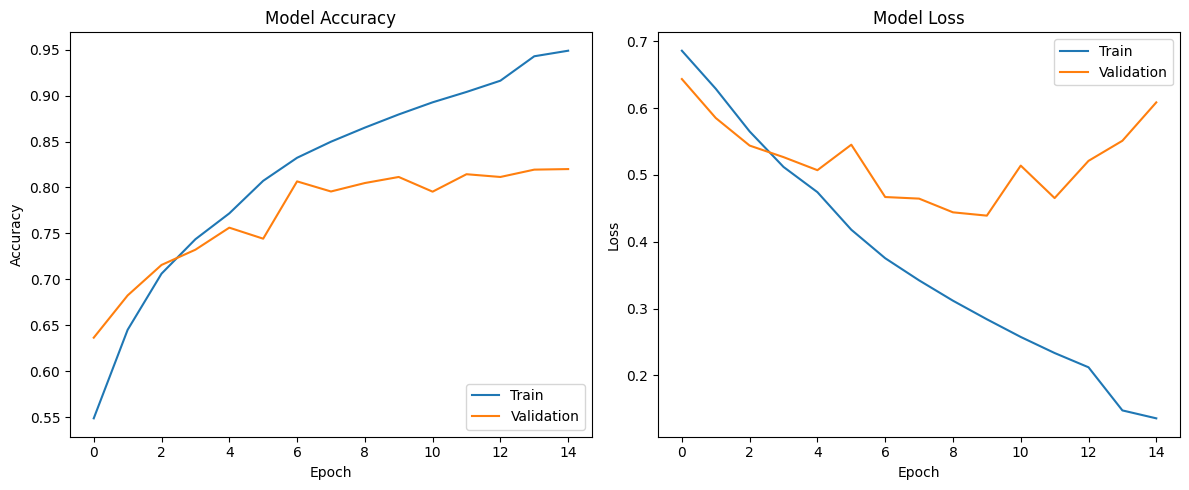

In [15]:
# Plot training history
try:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    print("Training history plot saved as 'training_history.png'")
except Exception as e:
    print(f"Could not generate plot: {e}")